In [1]:
from kaggle_environments import make

# env = make("orbit_wars", debug=True)
# print(f"Environment: {env.name} v{env.version}")
# print(f"Players: {env.specification.agents}")
# print(f"Max steps: {env.configuration.episodeSteps}")

from src.mechanics import calculate_score
from src.simple_agent import SimpleAgent
from src.nearest_planet_sniper import nearest_planet_sniper
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np



Loading environment cabt failed: dlopen(/Users/fcp/opt/anaconda3/envs/orbitwars/lib/python3.11/site-packages/kaggle_environments/envs/cabt/cg/libcg.so, 0x0006): tried: '/Users/fcp/opt/anaconda3/envs/orbitwars/lib/python3.11/site-packages/kaggle_environments/envs/cabt/cg/libcg.so' (not a mach-o file), '/System/Volumes/Preboot/Cryptexes/OS/Users/fcp/opt/anaconda3/envs/orbitwars/lib/python3.11/site-packages/kaggle_environments/envs/cabt/cg/libcg.so' (no such file), '/Users/fcp/opt/anaconda3/envs/orbitwars/lib/python3.11/site-packages/kaggle_environments/envs/cabt/cg/libcg.so' (not a mach-o file)
Loading environment open_spiel_env failed: No module named 'pyspiel'


In [1]:
###CONFIG###
#testing simple agent


AGENT = SimpleAgent(roi_threshold=1.5)

def agent(obs):
    return AGENT.predict(obs)
AGENT_TO_TEST = agent

OPPONENT_AGENTS = [nearest_planet_sniper, "random"]

Loading environment cabt failed: dlopen(/Users/fcp/opt/anaconda3/envs/orbitwars/lib/python3.11/site-packages/kaggle_environments/envs/cabt/cg/libcg.so, 0x0006): tried: '/Users/fcp/opt/anaconda3/envs/orbitwars/lib/python3.11/site-packages/kaggle_environments/envs/cabt/cg/libcg.so' (not a mach-o file), '/System/Volumes/Preboot/Cryptexes/OS/Users/fcp/opt/anaconda3/envs/orbitwars/lib/python3.11/site-packages/kaggle_environments/envs/cabt/cg/libcg.so' (no such file), '/Users/fcp/opt/anaconda3/envs/orbitwars/lib/python3.11/site-packages/kaggle_environments/envs/cabt/cg/libcg.so' (not a mach-o file)
Loading environment open_spiel_env failed: No module named 'pyspiel'


In [ ]:
# Test our configured agent against all configured opponents

results = []

for opp in OPPONENT_AGENTS:
    opp_name = opp if isinstance(opp, str) else getattr(opp, "__name__", str(opp))

    env = make("orbit_wars", debug=True)
    env.run([AGENT_TO_TEST, opp])

    final = env.steps[-1]
    p0 = final[0]
    p1 = final[1]

    print(f"\n=== vs {opp_name} ===")
    print(f"Player 0 (AGENT_TO_TEST): reward={p0.reward}, status={p0.status}")
    print(f"Player 1 ({opp_name}): reward={p1.reward}, status={p1.status}")

    results.append(
        {
            "opponent": opp_name,
            "p0_reward": p0.reward,
            "p1_reward": p1.reward,
            "p0_status": p0.status,
            "p1_status": p1.status,
            "steps": len(env.steps),
        }
    )

    #calculate score

    final_obs = env.steps[-1][0].observation

    p0_score = calculate_score(final_obs, player_id=0)
    p1_score = calculate_score(final_obs, player_id=1)
    print("Final state:")
    print(f"Player 0 score: {p0_score:.4f}")
    print(f"Player 1 score: {p1_score:.4f}")
    print("Num steps:", len(env.steps))
    

    #Render match if user wants to 
    should_render = input(f"Render match vs {opp_name}? (y/n) ").strip().lower()
    if should_render == "y":
        env.render(mode="ipython", width=800, height=600)

# Optional: render last match played
# env.render(mode="ipython", width=800, height=600)



In [4]:
#single opponent multiple testing
#also want to try multiple roi thresholds

thresholds = [1.0, 1.15, 1.3, 1.45, 1.6, 1.75]
opp = nearest_planet_sniper

opp_name = opp if isinstance(opp, str) else getattr(opp, "__name__", str(opp))

env = make("orbit_wars", debug=True)

#table for game results and rewards for each threshold, ten games each
df = pd.DataFrame(columns=["threshold", "opponent", "p0_reward", "p1_reward", "p0_status", "p1_status", "steps"])
score_progressions = pd.DataFrame(columns=["threshold", "opponent", "step", "p0_score", "p1_score"])

for threshold in thresholds:
    agent = SimpleAgent(roi_threshold=threshold)
    def agent_fn(obs):
        return agent.predict(obs)
    
    for i in range(50):

        env.run([agent_fn, opp])

        final = env.steps[-1]
        p0 = final[0]
        p1 = final[1]

        print(f"\n=== vs {opp_name} ===")
        print(f"Player 0 (AGENT_TO_TEST): reward={p0.reward}, status={p0.status}")
        print(f"Player 1 ({opp_name}): reward={p1.reward}, status={p1.status}")
        #calculate score


        final_obs = env.steps[-1][0].observation

        p0_score = calculate_score(final_obs, player_id=0)
        p1_score = calculate_score(final_obs, player_id=1)

        #append to dataframe
        next_row = pd.DataFrame(
            {
                "threshold": [threshold],
                "opponent": [opp_name],
                "p0_reward": [p0.reward],
                "p1_reward": [p1.reward],
                "p0_status": [p0.status],
                "p1_status": [p1.status],
                "steps": [len(env.steps)],
                "p0_score": [p0_score],
                "p1_score": [p1_score],
            }
        )

        df = pd.concat([df, next_row], ignore_index=True)


        print(f"---Game {i}---")
        print("Final state:")
        print(f"Player 0 score: {p0_score:.4f}")
        print(f"Player 1 score: {p1_score:.4f}")
        print("Num steps:", len(env.steps))

        #lets also get score progression over time for the game, intervals of 15 steps
        for step_idx, step in enumerate(env.steps):
            if step_idx % 15 == 0 or step_idx == len(env.steps) - 1:
                obs = step[0].observation
                p0_score = calculate_score(obs, player_id=0)
                p1_score = calculate_score(obs, player_id=1)

                score_progressions = pd.concat(
                    [
                        score_progressions,
                        pd.DataFrame(
                            {
                                "game_number": [i],
                                "threshold": [threshold],
                                "opponent": [opp_name],
                                "step": [step_idx],
                                "p0_score": [p0_score],
                                "p1_score": [p1_score],
                            }
                        ),
                    ],
                    ignore_index=True,
                )



        #Render match if user wants to 
        # should_render = input(f"Render match vs {opp_name}? (y/n) ").strip().lower()
        # if should_render == "y":
        #     env.render(mode="ipython", width=800, height=600)

        env.reset()






=== vs nearest_planet_sniper ===
Player 0 (AGENT_TO_TEST): reward=-1, status=DONE
Player 1 (nearest_planet_sniper): reward=1, status=DONE
---Game 0---
Final state:
Player 0 score: 0.0000
Player 1 score: 4682.0000
Num steps: 310

=== vs nearest_planet_sniper ===
Player 0 (AGENT_TO_TEST): reward=1, status=DONE
Player 1 (nearest_planet_sniper): reward=-1, status=DONE
---Game 1---
Final state:
Player 0 score: 1916.2000
Player 1 score: 0.0000
Num steps: 195

=== vs nearest_planet_sniper ===
Player 0 (AGENT_TO_TEST): reward=1, status=DONE
Player 1 (nearest_planet_sniper): reward=-1, status=DONE
---Game 2---
Final state:
Player 0 score: 3828.4000
Player 1 score: 0.0000
Num steps: 195

=== vs nearest_planet_sniper ===
Player 0 (AGENT_TO_TEST): reward=-1, status=DONE
Player 1 (nearest_planet_sniper): reward=1, status=DONE
---Game 3---
Final state:
Player 0 score: 0.0000
Player 1 score: 2539.8000
Num steps: 287

=== vs nearest_planet_sniper ===
Player 0 (AGENT_TO_TEST): reward=1, status=DONE
Pl

In [7]:
score_progressions.head()
score_progressions.to_csv("score_progressions.csv", index=False)



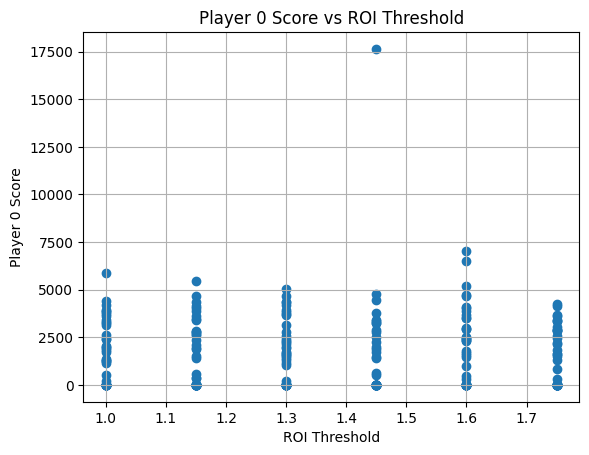

In [5]:
#scatter plot of rewards vs thresholds

plt.scatter(df["threshold"], df["p0_score"])
plt.xlabel("ROI Threshold")
plt.ylabel("Player 0 Score")
plt.title("Player 0 Score vs ROI Threshold")
plt.grid()
plt.show()


Threshold: 1.00 | Mean Score: 1464.5667 | Std: 1738.4950 | 95% CI: [842.4542, 2086.6791]
Threshold: 1.15 | Mean Score: 1304.2333 | Std: 1543.1156 | 95% CI: [752.0365, 1856.4301]
Threshold: 1.30 | Mean Score: 879.1467 | Std: 1590.2166 | 95% CI: [310.0950, 1448.1984]
Threshold: 1.45 | Mean Score: 1464.3867 | Std: 1799.8819 | 95% CI: [820.3072, 2108.4662]
Threshold: 1.60 | Mean Score: 1512.5867 | Std: 1452.3525 | 95% CI: [992.8690, 2032.3043]
Threshold: 1.75 | Mean Score: 1116.4667 | Std: 1562.1606 | 95% CI: [557.4547, 1675.4787]


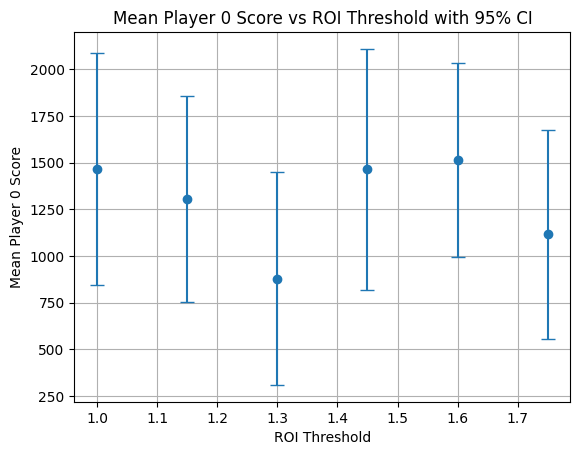

In [13]:
#print mean, std, and confidence intervals for each threshold
import numpy as np
mean_scores = []
ci_lowers = []
ci_uppers = []

for threshold in thresholds:
    subset = df[df["threshold"] == threshold]
    mean_score = subset["p0_score"].mean()
    std_score = subset["p0_score"].std()
    ci_lower = mean_score - 1.96 * (std_score / math.sqrt(len(subset)))
    ci_upper = mean_score + 1.96 * (std_score / math.sqrt(len(subset)))
    print(f"Threshold: {threshold:.2f} | Mean Score: {mean_score:.4f} | Std: {std_score:.4f} | 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

    mean_scores.append(mean_score)
    ci_lowers.append(ci_lower)
    ci_uppers.append(ci_upper)

#graph mean score with error bars for confidence intervals
#may have to convert mean_scores and ci_lowers/uppers to numpy arrays to do error bars

mean_scores = np.array(mean_scores)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

plt.errorbar(thresholds, mean_scores, yerr=[mean_scores - ci_lowers, ci_uppers - mean_scores], fmt='o', capsize=5)
plt.xlabel("ROI Threshold")
plt.ylabel("Mean Player 0 Score")
plt.title("Mean Player 0 Score vs ROI Threshold with 95% CI")
plt.grid()
plt.show()  


In [8]:
#print number of wins for each threshold (win = p0_score > p1_score)
for threshold in thresholds:
    subset = df[df["threshold"] == threshold]
    wins = (subset["p0_score"] > subset["p1_score"]).sum()
    total = len(subset)
    print(f"Threshold: {threshold:.2f} | Wins: {wins}/{total} ({wins/total:.2%})")

Threshold: 1.00 | Wins: 27/50 (54.00%)
Threshold: 1.15 | Wins: 24/50 (48.00%)
Threshold: 1.30 | Wins: 28/50 (56.00%)
Threshold: 1.45 | Wins: 19/50 (38.00%)
Threshold: 1.60 | Wins: 28/50 (56.00%)
Threshold: 1.75 | Wins: 23/50 (46.00%)


In [6]:
#save results to csv
df.to_csv("agent_testing_results_30.csv", index=False)

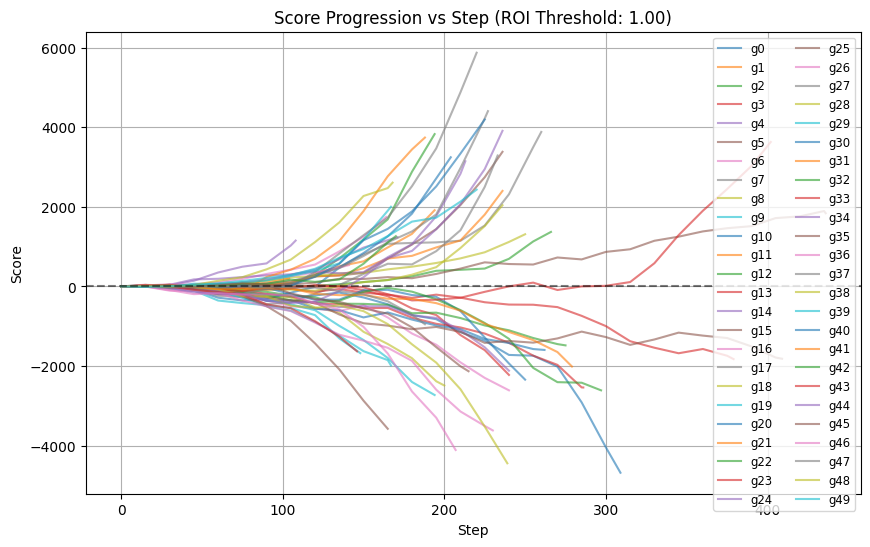

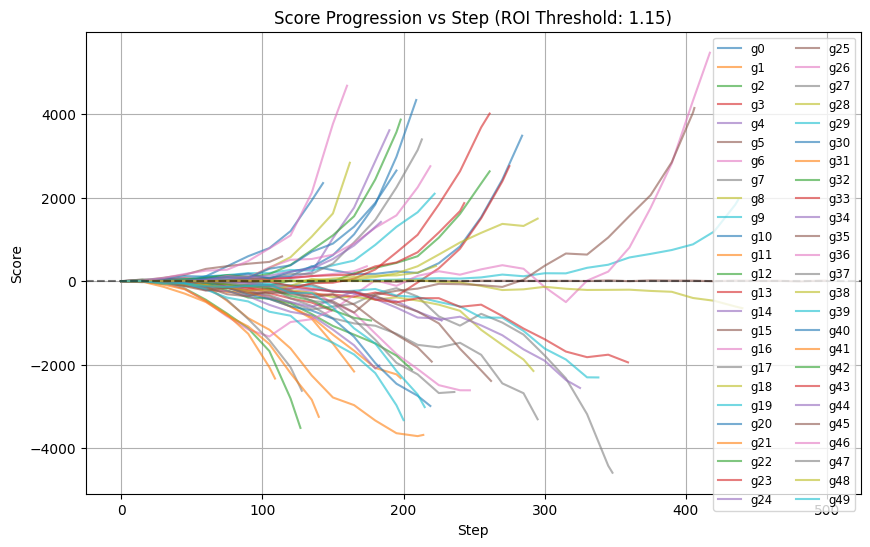

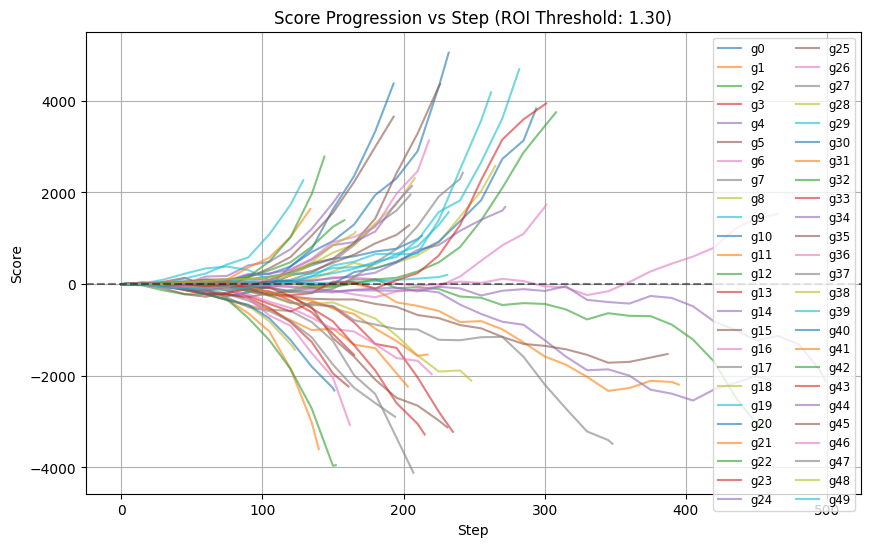

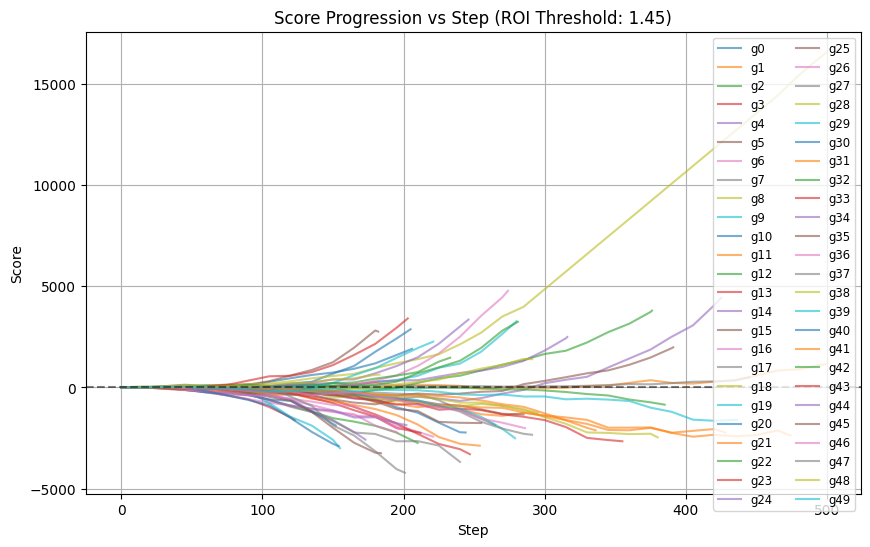

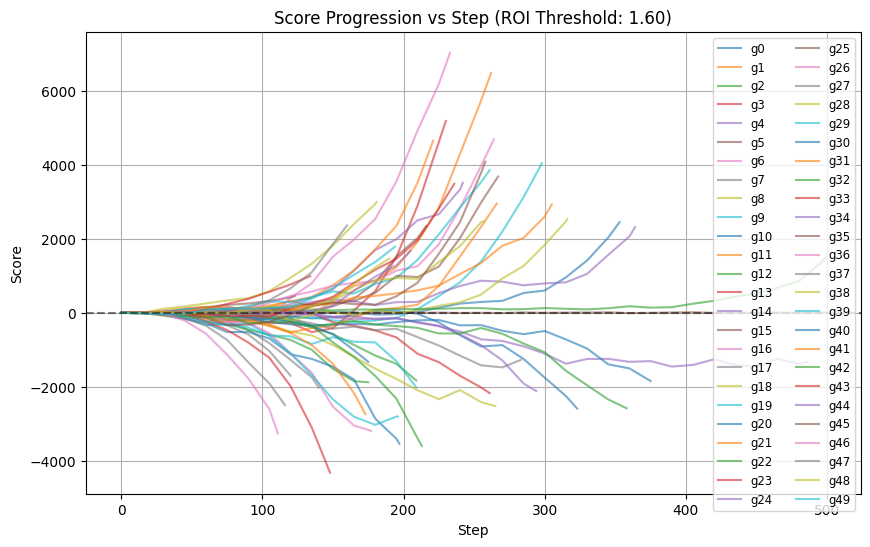

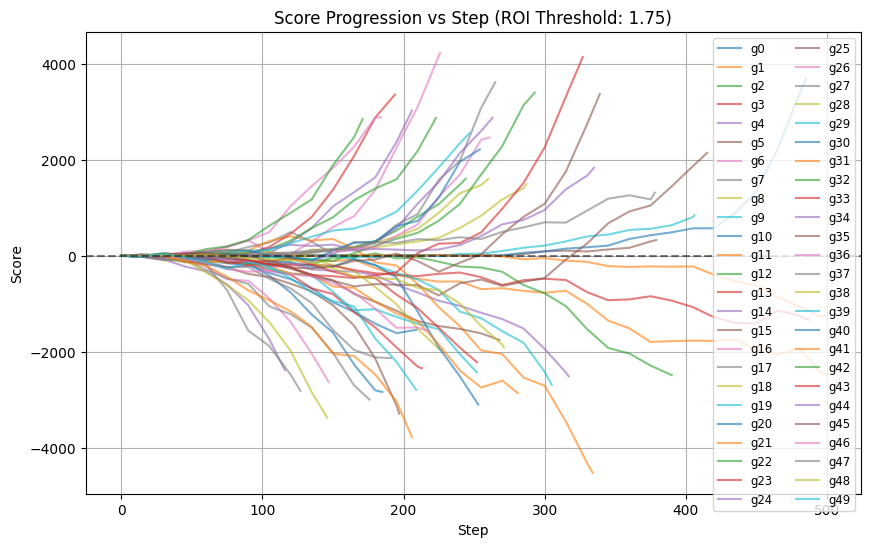

In [2]:
#graph mean score progressions for each threshold as a separate plot
#two lines per plot, one for p0 and one for p1, x axis is step, y axis is score, different color for each threshold

#reload data if not already in memory
score_progressions = pd.read_csv("score_progressions.csv")

thresholds = score_progressions["threshold"].unique()
import seaborn as sns

for threshold in thresholds:
    subset = score_progressions[score_progressions["threshold"] == threshold]
    plt.figure(figsize=(10, 6))
    game_nums = sorted(subset["game_number"].unique())
    for g in game_nums:
        gdf = subset[subset["game_number"] == g]
        #plot just the delta between p0 and p1 scores over time, with a horizontal line at y=0 to show when they are equal
        plt.plot(gdf["step"], gdf["p0_score"] - gdf["p1_score"], alpha=0.6, label=f"g{int(g)}")
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.xlabel("Step")
    plt.ylabel("Score")
    plt.title(f"Score Progression vs Step (ROI Threshold: {threshold:.2f})")
    plt.legend(ncol=2, fontsize="small")
    plt.grid()
    plt.show()